# FraudShield — PaySim Exploratory Data Analysis

## Objective
Analyze the PaySim synthetic mobile-money dataset to understand:

- Dataset structure and schema
- Fraud/legitimate class imbalance
- Transaction types and distributions
- Missing values and duplicates
- Fraud patterns
- Potential data leakage
- Features suitable for the FraudShield transaction-risk model

### Important
PaySim is used as a proxy for UPI-like transaction behaviour.
It is synthetic mobile-money data, not real UPI transaction data.

The final transaction model will use XGBoost, with SHAP for explainability.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Environment ready.")

Environment ready.


In [2]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ealaxi/paysim1/PS_20174392719_1491204439457_log.csv


In [3]:
DATA_PATH = "/kaggle/input/datasets/ealaxi/paysim1/PS_20174392719_1491204439457_log.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

Dataset loaded successfully.
Shape: (6362620, 11)


In [6]:
#Cell 5

display(df.head())

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
display(df.tail())

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0


In [7]:
#cell 6

print("Columns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2}. {col}")

print("\nData types:")
display(df.dtypes)

Columns:
 1. step
 2. type
 3. amount
 4. nameOrig
 5. oldbalanceOrg
 6. newbalanceOrig
 7. nameDest
 8. oldbalanceDest
 9. newbalanceDest
10. isFraud
11. isFlaggedFraud

Data types:


step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [8]:
#cell 7

print("Missing values:")
display(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


Total missing values: 0

Duplicate rows: 0


In [9]:
#cell 8

print("Fraud distribution:")
display(df["isFraud"].value_counts())

print("\nFraud percentage:")
fraud_percentage = df["isFraud"].mean() * 100
print(f"Fraud transactions: {fraud_percentage:.4f}%")
print(f"Legitimate transactions: {100 - fraud_percentage:.4f}%")

Fraud distribution:


isFraud
0    6354407
1       8213
Name: count, dtype: int64


Fraud percentage:
Fraud transactions: 0.1291%
Legitimate transactions: 99.8709%


In [10]:
#cell 9

print("Transaction type distribution:")
display(df["type"].value_counts())

print("\nFraud count by transaction type:")
display(
    pd.crosstab(
        df["type"],
        df["isFraud"]
    )
)

Transaction type distribution:


type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


Fraud count by transaction type:


isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


In [11]:
#cell 10

fraud_by_type = (
    df.groupby("type")["isFraud"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "total_transactions",
          "sum": "fraud_transactions",
          "mean": "fraud_rate"
      })
)

fraud_by_type["fraud_rate"] *= 100

display(fraud_by_type.sort_values("fraud_rate", ascending=False))

,total_transactions,fraud_transactions,fraud_rate
type,,,
TRANSFER,532909,4097,0.768799
CASH_OUT,2237500,4116,0.183955
CASH_IN,1399284,0,0.000000
DEBIT,41432,0,0.000000
PAYMENT,2151495,0,0.000000


In [12]:
#cell 11

print("Amount statistics:")
display(df["amount"].describe())

Amount statistics:


count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64

In [14]:
#cell 12

print("Amount statistics by fraud status:")
display(
    df.groupby("isFraud")["amount"]
      .describe()
)

Amount statistics by fraud status:


,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


## Data Leakage and Feature Selection

PaySim contains balance fields that can encode information created by the simulated transaction outcome.

For FraudShield, the model must predict risk **before payment completion**, so features that depend on post-transaction state should not be used as direct predictive inputs.

We will therefore investigate:

- `oldbalanceOrg`
- `newbalanceOrig`
- `oldbalanceDest`
- `newbalanceDest`
- `isFlaggedFraud`

We will also treat `nameOrig` and `nameDest` as identifiers rather than raw model features.

The goal is to build a feature set that represents information available at or before the payment decision.

In [16]:
#cell 13

# Compare balance behaviour between legitimate and fraudulent transactions

balance_cols = [
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]

balance_summary = df.groupby("isFraud")[balance_cols].agg(
    ["mean", "median", "min", "max"]
)

display(balance_summary)

oldbalanceOrg                              newbalanceOrig              \
                 mean     median  min          max           mean median  min   
isFraud                                                                         
0        8.328287e+05   14069.00  0.0  43818855.30  855970.228109    0.0  0.0   
1        1.649668e+06  438983.45  0.0  59585040.37  192392.631836    0.0  0.0   

                     oldbalanceDest                               \
                 max           mean    median  min           max   
isFraud                                                            
0        43686616.33   1.101421e+06  133311.8  0.0  3.560159e+08   
1        49585040.37   5.442496e+05       0.0  0.0  2.362305e+08   

        newbalanceDest                                
                  mean     median  min           max  
isFraud                                               
0         1.224926e+06  214881.70  0.0  3.561793e+08  
1         1.279708e+06    4676.42  0.0  2.367265e+08

In [17]:
#cell 14

# Check the relationship between amount and origin balance

df["origin_balance_difference"] = (
    df["oldbalanceOrg"] - df["newbalanceOrig"]
)

df["destination_balance_difference"] = (
    df["newbalanceDest"] - df["oldbalanceDest"]
)

display(
    df.groupby("isFraud")[
        [
            "origin_balance_difference",
            "destination_balance_difference"
        ]
    ].describe()
)

origin_balance_difference                                         \
                            count          mean           std        min   
isFraud                                                                    
0                       6354407.0 -2.314152e+04  1.062233e+05 -1915267.9   
1                          8213.0  1.457275e+06  2.396099e+06        0.0   

                                                         \
               25%        50%          75%          max   
isFraud                                                   
0             0.00       0.00    10102.125   4164236.31   
1        124582.58  436317.49  1503034.860  10000000.00   

        destination_balance_difference                               \
                                 count           mean           std   
isFraud                                                               
0                            6354407.0  123504.809994  8.104223e+05   
1                               8213.0  735457.998071  1.856984e+06   

                                                         
                 min  25%  50%        75%           max  
isFraud                                                  
0       -13060826.21  0.0  0.0  148982.64  1.056878e+08  
1         -315226.07  0.0  0.0  445257.43  1.491511e+07

In [18]:
#cell 15

# Examine isFlaggedFraud

print("isFlaggedFraud distribution:")
display(df["isFlaggedFraud"].value_counts())

print("\nFraud rate by isFlaggedFraud:")
display(
    df.groupby("isFlaggedFraud")["isFraud"]
      .agg(["count", "sum", "mean"])
)

isFlaggedFraud distribution:


isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64


Fraud rate by isFlaggedFraud:


,count,sum,mean
isFlaggedFraud,,,
0,6362604,8197,0.001288
1,16,16,1.000000


## Feature Selection Decision

For the first FraudShield transaction model:

### Excluded
- `newbalanceOrig` — post-transaction value
- `newbalanceDest` — post-transaction value
- `nameOrig` — identifier
- `nameDest` — identifier
- `isFlaggedFraud` — existing PaySim fraud flag

### Candidate features
- `step`
- `type`
- `amount`
- `oldbalanceOrg`
- `oldbalanceDest`

Two feature sets will later be evaluated:

1. PaySim baseline feature set
2. FraudShield pre-payment feature set

The final production-oriented design will prioritize signals that can realistically be available before payment completion.

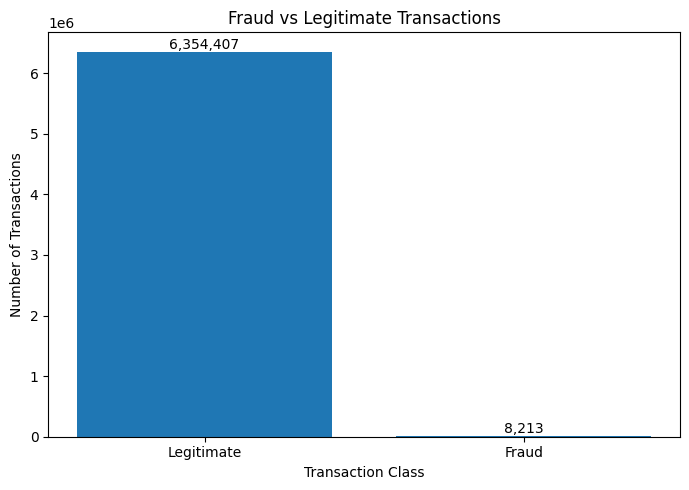

In [19]:
#cell 16

# Fraud vs legitimate transactions

fraud_counts = df["isFraud"].value_counts().sort_index()

labels = ["Legitimate", "Fraud"]

plt.figure(figsize=(7, 5))
plt.bar(labels, fraud_counts.values)

plt.title("Fraud vs Legitimate Transactions")
plt.ylabel("Number of Transactions")
plt.xlabel("Transaction Class")

for i, value in enumerate(fraud_counts.values):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

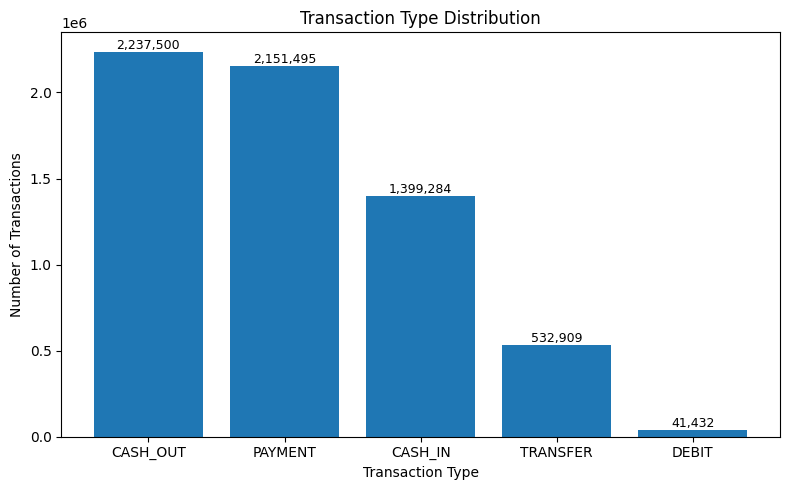

In [20]:
#cell 17

# Transaction type distribution

type_counts = df["type"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(type_counts.index, type_counts.values)

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

for i, value in enumerate(type_counts.values):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

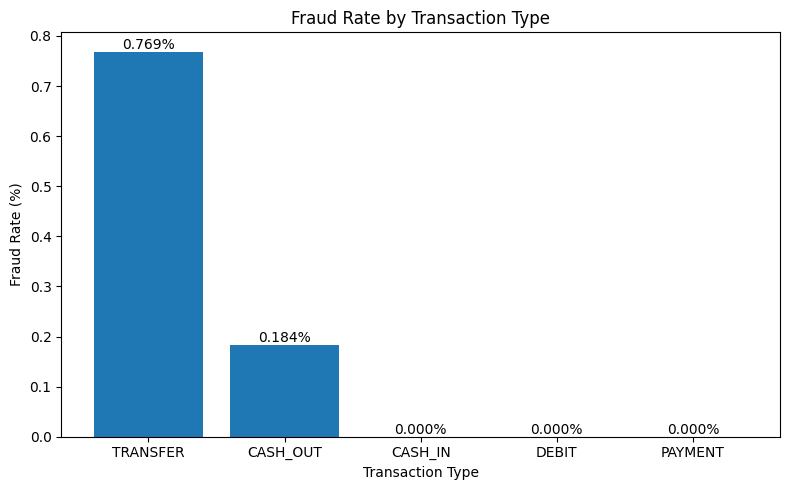

In [21]:
#cell 18

# Fraud rate by transaction type

fraud_rate_by_type = (
    df.groupby("type")["isFraud"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
plt.bar(fraud_rate_by_type.index, fraud_rate_by_type.values)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")

for i, value in enumerate(fraud_rate_by_type.values):
    plt.text(i, value, f"{value:.3f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

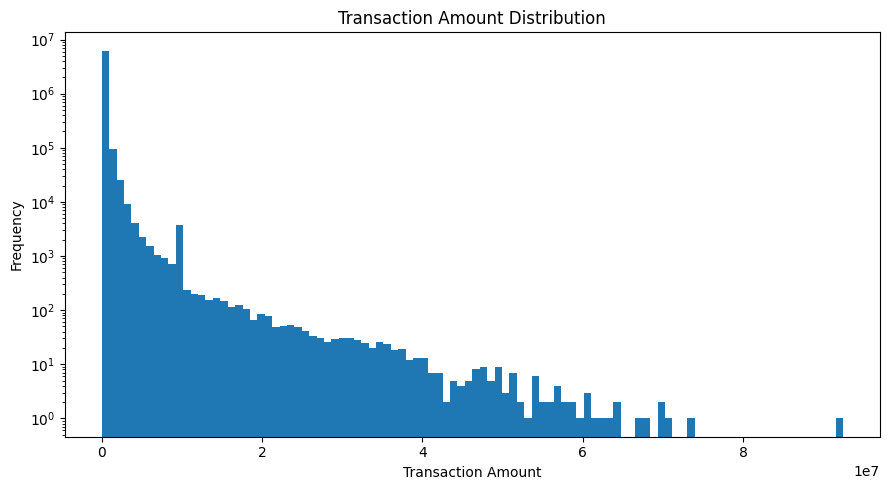

In [22]:
#cell 19

# Transaction amount distribution

plt.figure(figsize=(9, 5))
plt.hist(df["amount"], bins=100)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.yscale("log")

plt.tight_layout()
plt.show()

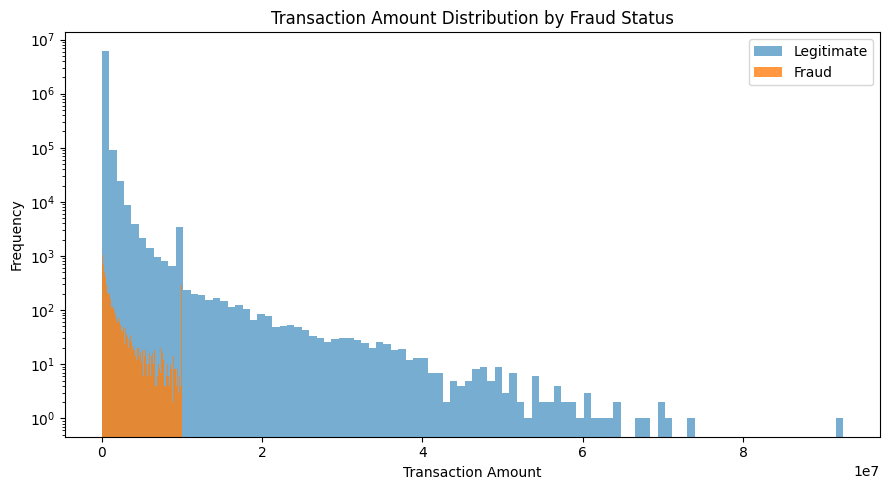

In [23]:
#cell 20

# Compare transaction amounts for legitimate and fraudulent transactions

legit_amounts = df.loc[df["isFraud"] == 0, "amount"]
fraud_amounts = df.loc[df["isFraud"] == 1, "amount"]

plt.figure(figsize=(9, 5))

plt.hist(
    legit_amounts,
    bins=100,
    alpha=0.6,
    label="Legitimate"
)

plt.hist(
    fraud_amounts,
    bins=100,
    alpha=0.8,
    label="Fraud"
)

plt.title("Transaction Amount Distribution by Fraud Status")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.yscale("log")
plt.legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_58/3075472074.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


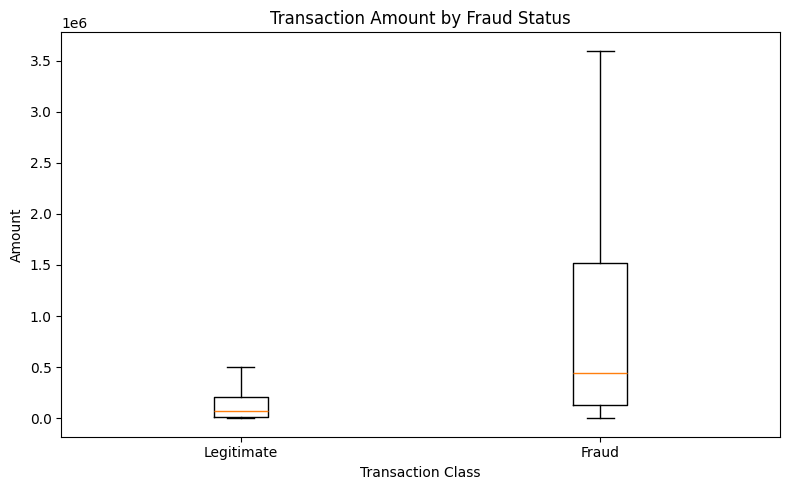

In [24]:
#cell 21

# Box plot of transaction amount by fraud status

plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        df.loc[df["isFraud"] == 0, "amount"],
        df.loc[df["isFraud"] == 1, "amount"]
    ],
    labels=["Legitimate", "Fraud"],
    showfliers=False
)

plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Transaction Class")
plt.ylabel("Amount")

plt.tight_layout()
plt.show()

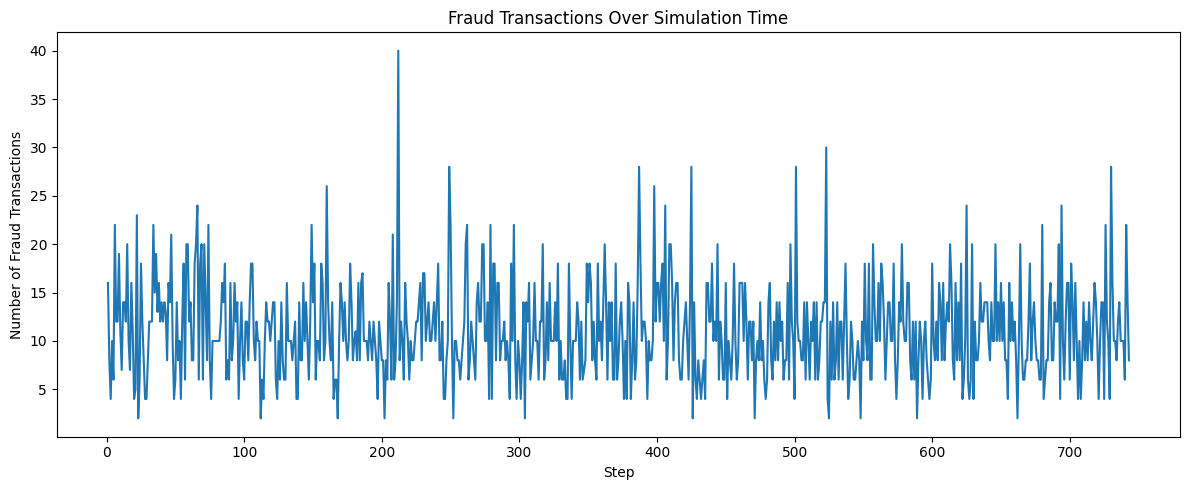

In [25]:
#cell 22

# Fraud transactions over simulation time

fraud_over_time = (
    df[df["isFraud"] == 1]
    .groupby("step")
    .size()
)

plt.figure(figsize=(12, 5))
plt.plot(fraud_over_time.index, fraud_over_time.values)

plt.title("Fraud Transactions Over Simulation Time")
plt.xlabel("Step")
plt.ylabel("Number of Fraud Transactions")

plt.tight_layout()
plt.show()

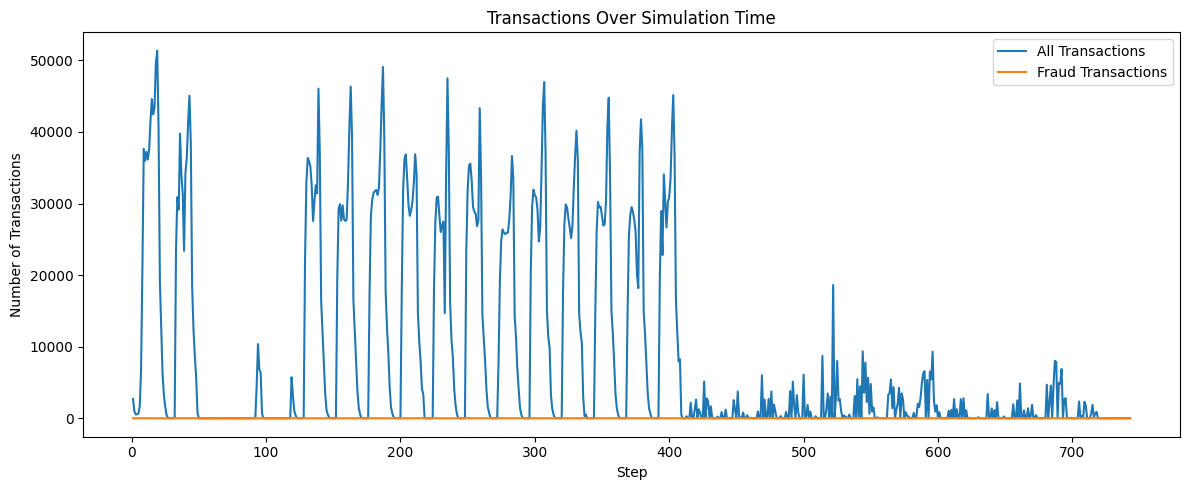

In [26]:
#cell 23

# Compare total and fraudulent transactions over time

total_over_time = df.groupby("step").size()
fraud_over_time = df[df["isFraud"] == 1].groupby("step").size()

plt.figure(figsize=(12, 5))

plt.plot(
    total_over_time.index,
    total_over_time.values,
    label="All Transactions"
)

plt.plot(
    fraud_over_time.index,
    fraud_over_time.values,
    label="Fraud Transactions"
)

plt.title("Transactions Over Simulation Time")
plt.xlabel("Step")
plt.ylabel("Number of Transactions")
plt.legend()

plt.tight_layout()
plt.show()

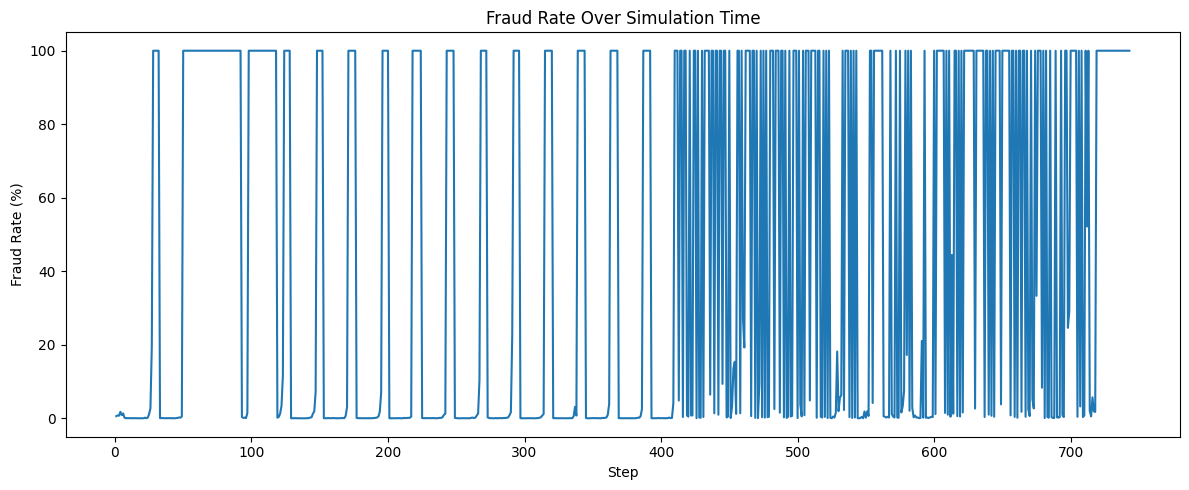

In [28]:
#cell 24

# Fraud rate over time

fraud_rate_over_time = (
    df.groupby("step")["isFraud"]
      .mean()
      .mul(100)
)

plt.figure(figsize=(12, 5))
plt.plot(fraud_rate_over_time.index, fraud_rate_over_time.values)

plt.title("Fraud Rate Over Simulation Time")
plt.xlabel("Step")
plt.ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.show()

In [29]:
#cell 25

# Final feature-selection summary for the first transaction model

feature_decision = pd.DataFrame({
    "Feature": [
        "step",
        "type",
        "amount",
        "oldbalanceOrg",
        "oldbalanceDest",
        "newbalanceOrig",
        "newbalanceDest",
        "nameOrig",
        "nameDest",
        "isFlaggedFraud"
    ],
    "Decision": [
        "KEEP",
        "KEEP",
        "KEEP",
        "CANDIDATE",
        "CANDIDATE",
        "DROP",
        "DROP",
        "DROP",
        "DROP",
        "DROP"
    ],
    "Reason": [
        "Temporal transaction information",
        "Transaction category",
        "Core transaction value",
        "Potential pre-transaction origin balance signal",
        "Potential destination-side balance signal",
        "Post-transaction value; leakage risk",
        "Post-transaction value; leakage risk",
        "Identifier; no useful raw predictive meaning",
        "Identifier; no useful raw predictive meaning",
        "Existing PaySim fraud flag; avoid using the dataset's own detection rule"
    ]
})

display(feature_decision)

,Feature,Decision,Reason
0,step,KEEP,Temporal transaction information
1,type,KEEP,Transaction category
2,amount,KEEP,Core transaction value
3,oldbalanceOrg,CANDIDATE,Potential pre-transaction origin balance signal
4,oldbalanceDest,CANDIDATE,Potential destination-side balance signal
5,newbalanceOrig,DROP,Post-transaction value; leakage risk
6,newbalanceDest,DROP,Post-transaction value; leakage risk
7,nameOrig,DROP,Identifier; no useful raw predictive meaning
8,nameDest,DROP,Identifier; no useful raw predictive meaning
9,isFlaggedFraud,DROP,Existing PaySim fraud flag; avoid using the da...


In [30]:
#cell 26

# Initial feature sets to evaluate later

paysim_baseline_features = [
    "step",
    "type",
    "amount",
    "oldbalanceOrg",
    "oldbalanceDest"
]

fraudshield_core_features = [
    "step",
    "type",
    "amount",
    "oldbalanceOrg"
]

print("PaySim baseline features:")
print(paysim_baseline_features)

print("\nFraudShield core pre-payment features:")
print(fraudshield_core_features)

PaySim baseline features:
['step', 'type', 'amount', 'oldbalanceOrg', 'oldbalanceDest']

FraudShield core pre-payment features:
['step', 'type', 'amount', 'oldbalanceOrg']
